# Dataset 2 – Oxford Parkinson's Disease Detection
**Implementation:** Vishal Hanuman  
**Algorithms:** k-NN (HW1) · Gaussian Naive Bayes (HW2) · Random Forest (HW3) · Neural Network (HW4)  
**Evaluation:** Stratified 10-fold CV · Accuracy · Macro F1

In [23]:
import sys, os, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not Path('algorithms').exists():
    subprocess.run(['git', 'clone', 'https://github.com/vishalhanuman14/classical-ml-benchmark.git'], check=True)
    os.chdir('classical-ml-benchmark')

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'algorithms').exists() and (PROJECT_ROOT.parent / 'algorithms').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')


Project root: /home/vishal/code/classical-ml-benchmark


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from algorithms.vishal import knn, naive_bayes, random_forest, utils

np.random.seed(42)

df = pd.read_csv('data/parkinsons.csv')
print(df.head(2))
print(f"Shape: {df.shape}, Columns: {list(df.columns)}")


   MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  \
0      119.992       157.302        74.997         0.00784           0.00007   
1      122.400       148.650       113.819         0.00968           0.00008   

   MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  ...  \
0   0.00370   0.00554     0.01109       0.04374             0.426  ...   
1   0.00465   0.00696     0.01394       0.06134             0.626  ...   

   Shimmer:DDA      NHR     HNR      RPDE       DFA   spread1   spread2  \
0      0.06545  0.02211  21.033  0.414783  0.815285 -4.813031  0.266482   
1      0.09403  0.01929  19.085  0.458359  0.819521 -4.075192  0.335590   

         D2       PPE  Diagnosis  
0  2.301442  0.284654          1  
1  2.486855  0.368674          1  

[2 rows x 23 columns]
Shape: (195, 23), Columns: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(d

In [25]:
# 'Diagnosis' is the target (0=healthy, 1=Parkinson's); drop 'name' column
df = df.drop(columns=['name'], errors='ignore')
target_col = 'Diagnosis'
X_raw = df.drop(columns=[target_col]).values.astype(float)
y     = df[target_col].values.astype(str)
X_norm, _ = utils.normalize(X_raw, X_raw)

print(f"Instances: {len(y)}, Features: {X_norm.shape[1]}, Classes: {dict(zip(*np.unique(y, return_counts=True)))}")


Instances: 195, Features: 22, Classes: {np.str_('0'): np.int64(48), np.str_('1'): np.int64(147)}


## k-NN – Hyperparameter Sweep (k)

In [26]:
K_VALUES  = [1, 3, 5, 7, 11, 15, 21, 31]
knn_results = {}

for k in K_VALUES:
    def model_fn(Xtr, ytr, Xte, k=k):
        Xtr_n, Xte_n = utils.normalize(Xtr, Xte)
        return knn.predict(Xtr_n, ytr, Xte_n, k)

    acc, f1 = utils.cross_validate(model_fn, X_raw, y, pos_label='1')
    knn_results[k] = (acc, f1)
    print(f"k={k:>3}  acc={acc:.4f}  f1={f1:.4f}")


k=  1  acc=0.9544  f1=0.9676
k=  3  acc=0.9278  f1=0.9530
k=  5  acc=0.9278  f1=0.9528
k=  7  acc=0.9325  f1=0.9565
k= 11  acc=0.8917  f1=0.9319
k= 15  acc=0.8420  f1=0.9034
k= 21  acc=0.8373  f1=0.9028
k= 31  acc=0.8403  f1=0.9047


## Naive Bayes – Hyperparameter Sweep (none / log-variance smoothing)

In [27]:
# NB has no major hyperparameter; sweep a small additive variance floor (epsilon)
EPSILONS  = [1e-9, 1e-7, 1e-5, 1e-3, 0.01, 0.1]
nb_results = {}

for eps in EPSILONS:
    def model_fn(Xtr, ytr, Xte, eps=eps):
        import algorithms.vishal.naive_bayes as nb_mod
        import importlib, types
        # Patch std floor for this run
        m = nb_mod.train(Xtr, ytr)
        for c in m['classes']:
            m['stds'][c] = np.maximum(m['stds'][c], eps)
        return nb_mod.predict(m, Xte)

    acc, f1 = utils.cross_validate(model_fn, X_norm, y, pos_label='1')
    nb_results[eps] = (acc, f1)
    print(f"eps={eps}  acc={acc:.4f}  f1={f1:.4f}")


eps=1e-09  acc=0.6915  f1=0.7423
eps=1e-07  acc=0.6968  f1=0.7479
eps=1e-05  acc=0.6979  f1=0.7504
eps=0.001  acc=0.6929  f1=0.7497
eps=0.01  acc=0.7129  f1=0.7651
eps=0.1  acc=0.7171  f1=0.7695


## Random Forest – Hyperparameter Sweep (ntree)

In [28]:
feature_types = ['num'] * X_norm.shape[1]
NTREE_VALUES  = [5, 10, 20, 30, 50, 75, 100, 150]
rf_results    = {}

for nt in NTREE_VALUES:
    def model_fn(Xtr, ytr, Xte, nt=nt):
        trees = random_forest.train(Xtr, ytr, feature_types, nt)
        return random_forest.predict(trees, Xte)

    acc, f1 = utils.cross_validate(model_fn, X_norm, y, pos_label='1')
    rf_results[nt] = (acc, f1)
    print(f"ntree={nt:>4}  acc={acc:.4f}  f1={f1:.4f}")


ntree=   5  acc=0.8554  f1=0.9055
ntree=  10  acc=0.8817  f1=0.9245
ntree=  20  acc=0.9014  f1=0.9376
ntree=  30  acc=0.8878  f1=0.9286
ntree=  50  acc=0.8920  f1=0.9327
ntree=  75  acc=0.8823  f1=0.9250
ntree= 100  acc=0.8928  f1=0.9324
ntree= 150  acc=0.8911  f1=0.9311


## Neural Network – Hyperparameter Sweep (architecture × lambda)

Binary output (single sigmoid neuron). Small dataset (195), so lighter architectures and more regularisation.

In [29]:
from algorithms.vishal import neural_network

# y_int needed for NN (binary: 0=healthy, 1=Parkinson's)
y_int = y.astype(int)
Y_bin = y_int.reshape(-1, 1).astype(float)   # shape (195, 1)

NN_CONFIGS = [
    ((8,),    0.0),
    ((16,),   0.0),
    ((8, 4),  0.0),
    ((16, 8), 0.0),
    ((8,),    0.1),
    ((16, 8), 0.1),
]

nn_results  = {}
folds_nn    = utils.stratified_k_fold(y, k=10)

for arch, lam in NN_CONFIGS:
    accs, f1s = [], []
    for i in range(10):
        test_idx  = np.array(folds_nn[i])
        train_idx = np.array([idx for j in range(10) if j != i for idx in folds_nn[j]])

        Xtr, Xte = X_norm[train_idx], X_norm[test_idx]
        Ytr      = Y_bin[train_idx]
        y_te_int = y_int[test_idx]

        layer_sizes = [X_norm.shape[1]] + list(arch) + [1]
        theta, _    = neural_network.train(Xtr, Ytr, layer_sizes,
                                           lam=lam, alpha=0.1,
                                           epochs=400, batch_size=16)
        y_pred = neural_network.predict(theta, Xte)
        acc, f1 = utils.compute_metrics(y_te_int, y_pred, pos_label=1)
        accs.append(acc); f1s.append(f1)

    nn_results[(arch, lam)] = (float(np.mean(accs)), float(np.mean(f1s)))
    print(f"arch={str(arch):<10} lam={lam}  acc={np.mean(accs):.4f}  f1={np.mean(f1s):.4f}")


arch=(8,)       lam=0.0  acc=0.8323  f1=0.8920
arch=(16,)      lam=0.0  acc=0.8378  f1=0.8968
arch=(8, 4)     lam=0.0  acc=0.7648  f1=0.8652
arch=(16, 8)    lam=0.0  acc=0.7659  f1=0.8627
arch=(8,)       lam=0.1  acc=0.8303  f1=0.8966
arch=(16, 8)    lam=0.1  acc=0.7542  f1=0.8598


Best NN: arch=(16,)  lam=0.0
  acc=0.8378  f1=0.8968


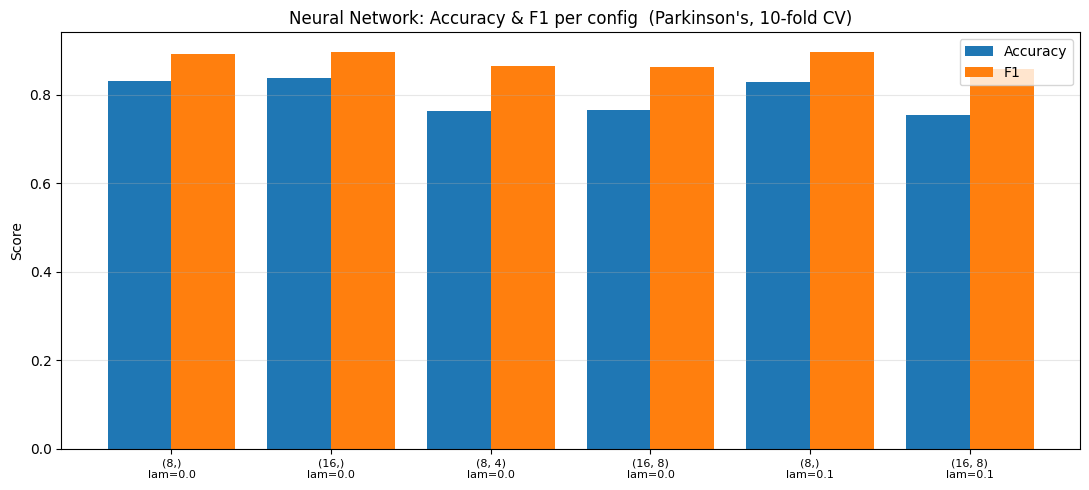

In [30]:
best_nn_key  = max(nn_results, key=lambda k: nn_results[k][1])
best_nn_arch, best_nn_lam = best_nn_key
print(f"Best NN: arch={best_nn_arch}  lam={best_nn_lam}")
print(f"  acc={nn_results[best_nn_key][0]:.4f}  f1={nn_results[best_nn_key][1]:.4f}")

labels = [f"{str(a)}\nlam={l}" for a, l in nn_results]
accs   = [nn_results[k][0] for k in nn_results]
f1s    = [nn_results[k][1] for k in nn_results]
x      = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.2, accs, 0.4, label='Accuracy')
ax.bar(x + 0.2, f1s,  0.4, label='F1')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Score')
ax.set_title("Neural Network: Accuracy & F1 per config  (Parkinson's, 10-fold CV)")
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout()
plt.savefig("results/parkinsons_nn_config_sweep.png", dpi=150); plt.show()


### Neural Network – Learning Curve (J vs training instances)

n=  10  J=0.7285
n=  25  J=0.5469
n=  40  J=0.5672
n=  55  J=0.5112
n=  70  J=0.5332
n=  85  J=0.5255
n= 100  J=0.5134
n= 115  J=0.4619
n= 130  J=0.4292
n= 145  J=0.4578
n= 156  J=0.4418


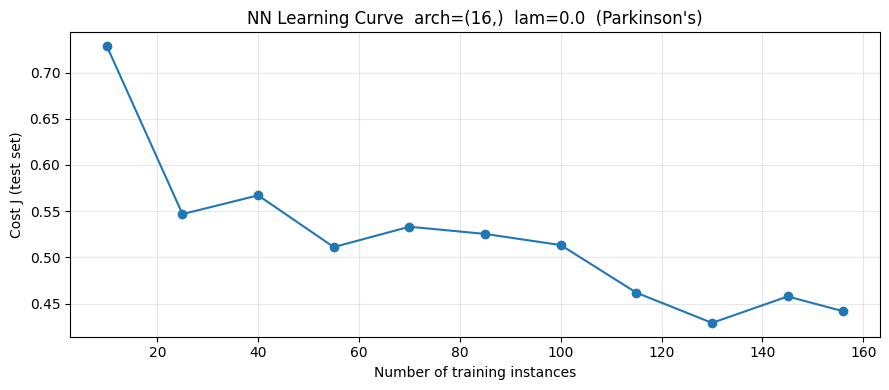

In [31]:
split = int(0.8 * len(y_int))
order = np.random.permutation(len(y_int))
tr_idx, te_idx = order[:split], order[split:]

Xtr_lc, Xte_lc = X_norm[tr_idx], X_norm[te_idx]
Ytr_lc = Y_bin[tr_idx]
Yte_lc = Y_bin[te_idx]

step   = max(10, split // 10)
sizes  = list(range(10, split + 1, step))
if sizes[-1] != split: sizes.append(split)

lc_costs   = []
ls_best_nn = [X_norm.shape[1]] + list(best_nn_arch) + [1]

for n in sizes:
    theta_lc, _ = neural_network.train(Xtr_lc[:n], Ytr_lc[:n], ls_best_nn,
                                        lam=best_nn_lam, alpha=0.1,
                                        epochs=400, batch_size=16)
    J, _, _ = neural_network.cost(Xte_lc, Yte_lc, theta_lc, best_nn_lam)
    lc_costs.append(J)
    print(f"n={n:>4}  J={J:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sizes, lc_costs, '-o')
ax.set_xlabel('Number of training instances')
ax.set_ylabel('Cost J (test set)')
ax.set_title(f"NN Learning Curve  arch={best_nn_arch}  lam={best_nn_lam}  (Parkinson's)")
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig("results/parkinsons_nn_learning_curve.png", dpi=150); plt.show()


## Plots & Summary

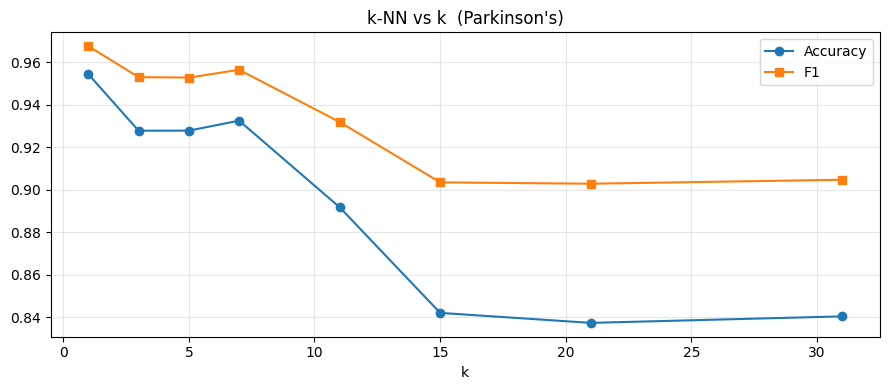

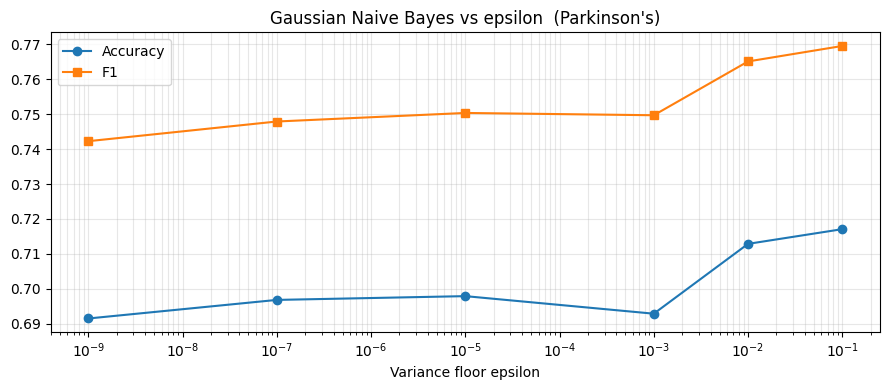

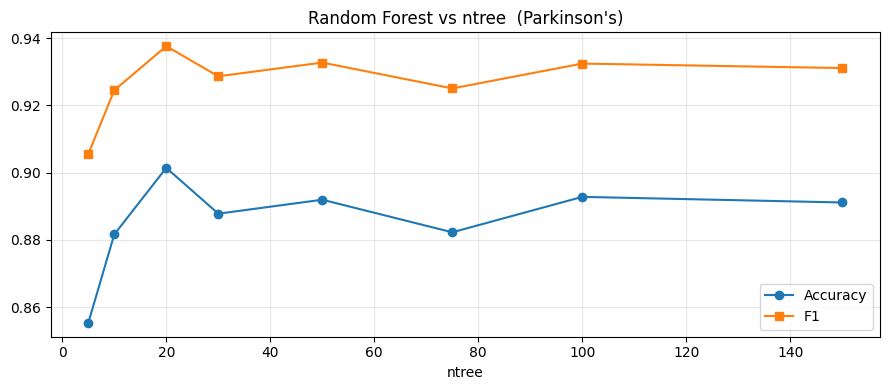

In [32]:
os.makedirs('results', exist_ok=True)

# k-NN curve
ks   = list(knn_results.keys())
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, [knn_results[k][0] for k in ks], '-o', label='Accuracy')
ax.plot(ks, [knn_results[k][1] for k in ks], '-s', label='F1')
ax.set_xlabel('k'); ax.set_title("k-NN vs k  (Parkinson's)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('results/parkinsons_knn_k_sweep.png', dpi=150); plt.show()

# Naive Bayes curve
eps_values = np.array(list(nb_results.keys()), dtype=float)
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(eps_values, [nb_results[e][0] for e in nb_results], '-o', label='Accuracy')
ax.semilogx(eps_values, [nb_results[e][1] for e in nb_results], '-s', label='F1')
ax.set_xlabel('Variance floor epsilon')
ax.set_title("Gaussian Naive Bayes vs epsilon  (Parkinson's)")
ax.legend(); ax.grid(alpha=0.3, which='both'); plt.tight_layout()
plt.savefig('results/parkinsons_nb_epsilon_sweep.png', dpi=150); plt.show()

# RF curve
nts = list(rf_results.keys())
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(nts, [rf_results[n][0] for n in nts], '-o', label='Accuracy')
ax.plot(nts, [rf_results[n][1] for n in nts], '-s', label='F1')
ax.set_xlabel('ntree'); ax.set_title("Random Forest vs ntree  (Parkinson's)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('results/parkinsons_rf_ntree_sweep.png', dpi=150); plt.show()


In [33]:
best_k   = max(knn_results, key=lambda k: knn_results[k][1])
best_eps = max(nb_results,  key=lambda e: nb_results[e][1])
best_nt  = max(rf_results,  key=lambda n: rf_results[n][1])

print(f"{'Algorithm':<25} {'Best HP':<18} {'Accuracy':>10} {'F1 Score':>10}")
print('-' * 68)
print(f"{'k-NN':<25} {'k='+str(best_k):<18} {knn_results[best_k][0]:>10.4f} {knn_results[best_k][1]:>10.4f}")
print(f"{'Naive Bayes':<25} {'eps='+str(best_eps):<18} {nb_results[best_eps][0]:>10.4f} {nb_results[best_eps][1]:>10.4f}")
print(f"{'Random Forest':<25} {'ntree='+str(best_nt):<18} {rf_results[best_nt][0]:>10.4f} {rf_results[best_nt][1]:>10.4f}")
print(f"{'Neural Network':<25} {str(best_nn_arch)+' l='+str(best_nn_lam):<18} {nn_results[best_nn_key][0]:>10.4f} {nn_results[best_nn_key][1]:>10.4f}")


Algorithm                 Best HP              Accuracy   F1 Score
--------------------------------------------------------------------
k-NN                      k=1                    0.9544     0.9676
Naive Bayes               eps=0.1                0.7171     0.7695
Random Forest             ntree=20               0.9014     0.9376
Neural Network            (16,) l=0.0            0.8378     0.8968
